### PART 1: environment setup & validation

#### 1.1 installation

In [2]:
%pip install -q opencv-python matplotlib numpy pandas


In [3]:
from pathlib import Path
import urllib.request

image_path = Path('cat.jpg')
image_url = 'https://commons.wikimedia.org/wiki/Special:Redirect/file/Domestic_cat.2.jpg'

if not image_path.exists():
    request = urllib.request.Request(image_url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(request, timeout=30) as response:
        image_path.write_bytes(response.read())

print(f'image ready: {image_path.resolve()}')


image ready: /content/cat.jpg


### 1.2 import & validate

In [4]:
import cv2
import matplotlib.pyplot as plt

In [5]:
print('OpenCV version:', cv2.__version__)
print('Matplotlib is working:', plt.figure is not None)


OpenCV version: 4.14.0
Matplotlib is working: True


### PART 2: python data structures & logic

#### task 1: object-oriented grocery manager

In [6]:
class GroceryManager:
    def __init__(self):

        self.items = {}

    def add_item(self, item, quantity, price):
        self.items[item] = {'quantity': quantity, 'price': price}
        print(f"added: {item} (qty: {quantity}, price: {price})")

    def remove_item(self, item):
        if item in self.items:
            del self.items[item]
            print(f"removed: {item}")
        else:
            print(f"'{item}' not found in the grocery list.")

    def view_list(self):
        if not self.items:
            print("grocery list is empty.")
            return
        print(f"{'item':<15}{'quantity':<10}{'price':<10}")
        for item, details in self.items.items():
            print(f"{item:<15}{details['quantity']:<10}{details['price']:<10}")

    def calculate_total(self):
        total = sum(d['quantity'] * d['price'] for d in self.items.values())
        print(f"total cost: {total}")
        return total

In [7]:
manager = GroceryManager()
manager.add_item("apples", 4, 50)
manager.add_item("milk", 2, 120)
manager.add_item("bread", 1, 90)

manager.view_list()
manager.calculate_total()

manager.remove_item("milk")
manager.remove_item("eggs")

manager.view_list()

added: apples (qty: 4, price: 50)
added: milk (qty: 2, price: 120)
added: bread (qty: 1, price: 90)
item           quantity  price     
apples         4         50        
milk           2         120       
bread          1         90        
total cost: 530
removed: milk
'eggs' not found in the grocery list.
item           quantity  price     
apples         4         50        
bread          1         90        


#### task 2: advanced student record system

In [8]:
students = {
    "S01": {"Name": "Areeba", "Major": "AI", "Grades": [85, 90, 78]},
    "S02": {"Name": "Emman", "Major": "CS", "Grades": [92, 88, 95]},
    "S03": {"Name": "Haris", "Major": "AI", "Grades": [70, 65, 80]},
    "S04": {"Name": "Huzaifa", "Major": "Data Sci", "Grades": [99, 94, 97]},
    "S05": {"Name": "Sabeeh", "Major": "CS", "Grades": [60, 72, 68]},
}

In [9]:
def top_student(records):
    best_name = None
    best_avg = -1
    for student_id, info in records.items():
        avg = sum(info["Grades"]) / len(info["Grades"])
        if avg > best_avg:
            best_avg = avg
            best_name = info["Name"]
    return best_name, best_avg

name, avg = top_student(students)
print(f"top student: {name} w/ avg grade {avg:.2f}")

top student: Huzaifa w/ avg grade 96.67


In [10]:
def students_by_major(records, major):
    found = [info["Name"] for info in records.values() if info["Major"] == major]
    if found:
        print(f"students in {major}: {', '.join(found)}")
    else:
        print(f"no students found in major: {major}")

students_by_major(students, "AI")
students_by_major(students, "CS")
students_by_major(students, "Philosophy")

students in AI: Areeba, Haris
students in CS: Emman, Sabeeh
no students found in major: Philosophy


### PART 3: core computer vision & matplotlib

#### task 3: safe image loading & RGB visualization

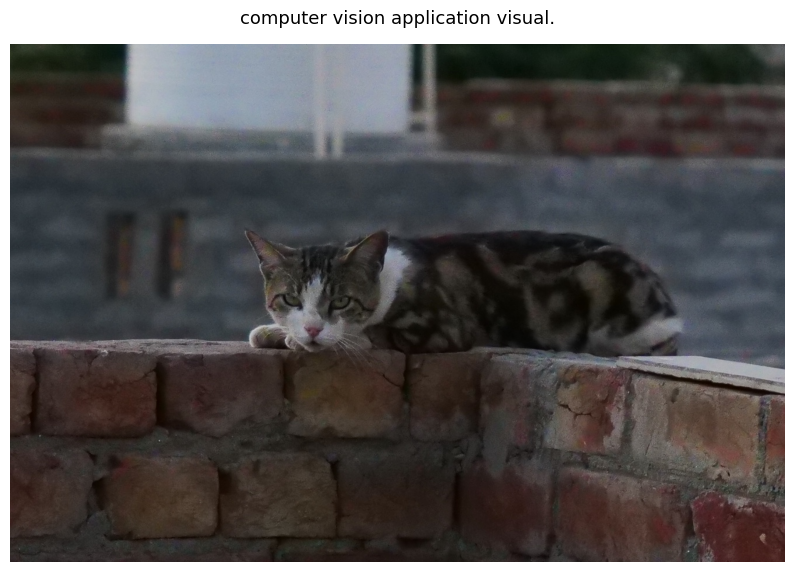

In [11]:
import cv2
import matplotlib.pyplot as plt

image_path = 'cat.jpg'
image = cv2.imread(image_path)

if image is None:
    print("no image found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,8))
    plt.axis('off')
    plt.title("computer vision application visual.", fontsize=13, color='black', pad=15)
    plt.imshow(image_rgb)
    plt.show()

#### task 4: interactive geometry & blank canvas

canvas center: (400, 400)


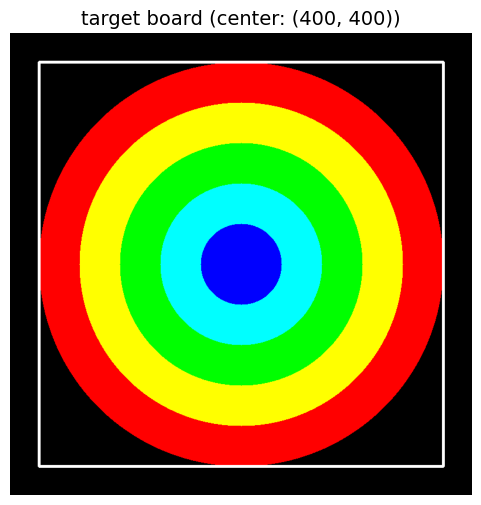

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


canvas = np.zeros((800,800, 3), dtype=np.uint8)


center_x, center_y = canvas.shape[1] // 2, canvas.shape[0] // 2
center = (center_x, center_y)
print(f"canvas center: {center}")


colors = [
    (0,0,255),
    (0,255,255),
    (0,255,0),
    (255,255,0),
    (255,0,0)
]


max_radius = 350
num_circles = 5
step = max_radius // num_circles

for i in range(num_circles):
    radius = max_radius - (i * step)
    color = colors[i % len(colors)]
    cv2.circle(canvas, center, radius, color, thickness=-1)


top_left = (center_x - max_radius, center_y - max_radius)
bottom_right = (center_x + max_radius, center_y + max_radius)
cv2.rectangle(canvas, top_left, bottom_right, (255,255,255), thickness=3)


canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(canvas_rgb)
plt.title(f'target board (center: {center})', fontsize=14)
plt.axis('off')
plt.show()

### task 5: advanced blurring & numpy ROI extraction

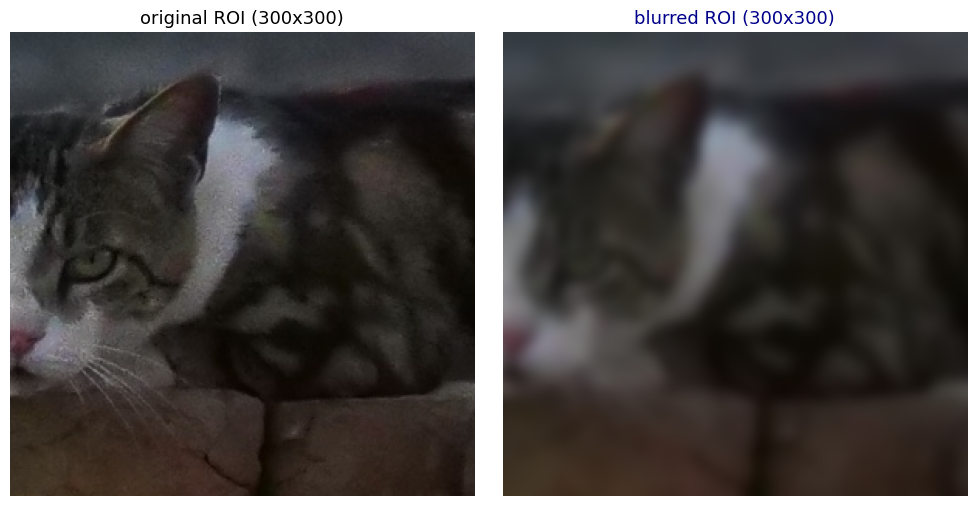

In [13]:
import cv2
import matplotlib.pyplot as plt

image_path = 'cat.jpg'
image = cv2.imread(image_path)

if image is None:
    print("image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    blurred_rgb = cv2.GaussianBlur(image_rgb, (25,25), 0)

    height, width = image_rgb.shape[:2]
    center_y, center_x = height //2, width //2


    roi_size = 300
    half = roi_size // 2

    y_start, y_end = center_y - half, center_y + half
    x_start, x_end = center_x - half, center_x + half

    original_roi = image_rgb[y_start:y_end, x_start:x_end]
    blurred_roi = blurred_rgb[y_start:y_end, x_start:x_end]

    fig, axes = plt.subplots(1, 2, figsize=(10,5))
    axes[0].imshow(original_roi)
    axes[0].set_title('original ROI (300x300)', fontsize=13, color='black')
    axes[0].axis('off')

    axes[1].imshow(blurred_roi)
    axes[1].set_title('blurred ROI (300x300)', fontsize=13, color='darkblue')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

#### task 6: alpha blending & typography

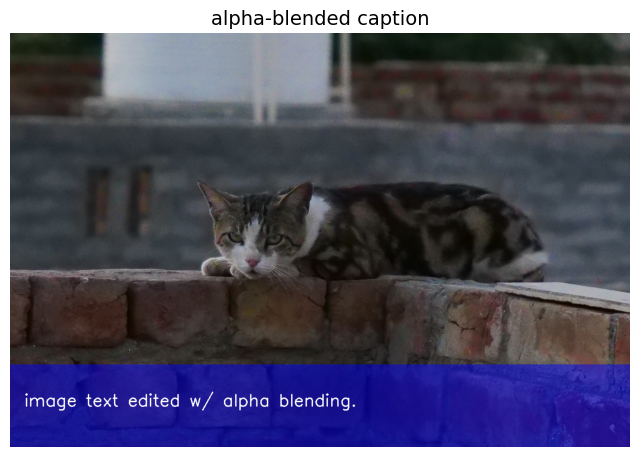

In [14]:
import cv2
import matplotlib.pyplot as plt

image_path = 'cat.jpg'
image = cv2.imread(image_path)

if image is None:
    print("image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image_rgb.shape[:2]

    overlay = image_rgb.copy()

    box_height = int(height * 0.20)
    y_start = height - box_height

    cv2.rectangle(overlay, (0, y_start), (width, height), (0,0,255), thickness=-1)

    alpha = 0.5
    blended = cv2.addWeighted(overlay, alpha, image_rgb, 1-alpha, 0)

    text = "image text edited w/ alpha blending."
    font = cv2.FONT_HERSHEY_SIMPLEX
    text_position = (30, height - box_height // 2)
    cv2.putText(blended, text, text_position, font, 1.2, (255, 255, 255), 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(blended)
    plt.title('alpha-blended caption', fontsize=14)
    plt.axis('off')
    plt.show()

#### task 7: matrix-based rotation & adaptive thresholding

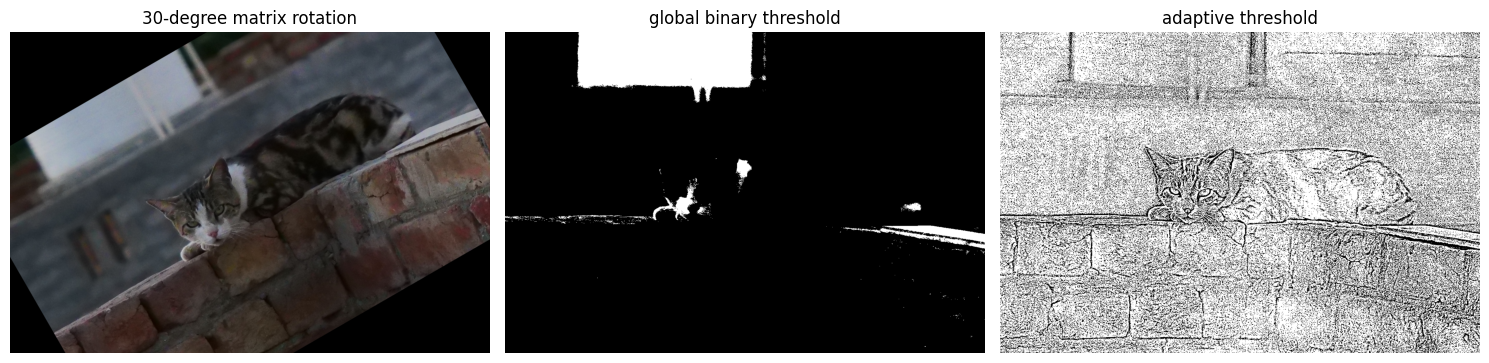

In [15]:
import cv2
import matplotlib.pyplot as plt

image_path = 'cat.jpg'
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f'Image not found: {image_path}')

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
height, width = image_rgb.shape[:2]
center = (width // 2, height // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 30, 1.0)
rotated = cv2.warpAffine(image_rgb, rotation_matrix, (width, height))

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, global_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
adaptive_thresh = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rotated)
axes[0].set_title('30-degree matrix rotation')
axes[0].axis('off')
axes[1].imshow(global_thresh, cmap='gray')
axes[1].set_title('global binary threshold')
axes[1].axis('off')
axes[2].imshow(adaptive_thresh, cmap='gray')
axes[2].set_title('adaptive threshold')
axes[2].axis('off')

plt.tight_layout()
plt.show()


#### task 8: masking with bitwise logic

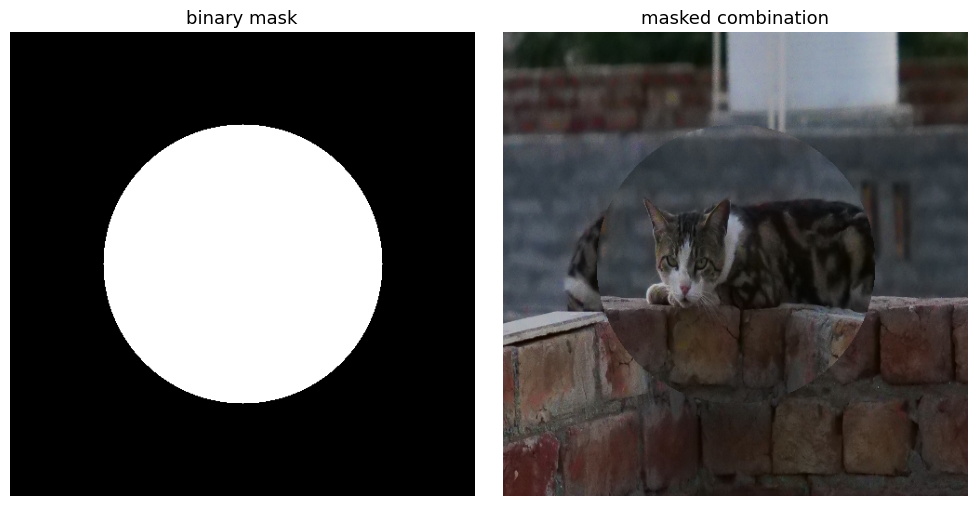

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image1 = cv2.imread('cat.jpg')
image2 = cv2.imread('cat.jpg')

if image1 is None or image2 is None:
    raise FileNotFoundError('cat.jpg could not be loaded.')

target_size = (500, 500)
image1 = cv2.resize(image1, target_size)
image2 = cv2.flip(cv2.resize(image2, target_size), 1)

mask = np.zeros((500, 500), dtype=np.uint8)
center = (250, 250)
radius = 150
cv2.circle(mask, center, radius, 255, thickness=-1)

foreground = cv2.bitwise_and(image1, image1, mask=mask)
inverse_mask = cv2.bitwise_not(mask)
background = cv2.bitwise_and(image2, image2, mask=inverse_mask)
combined = cv2.bitwise_or(foreground, background)

combined_rgb = cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('binary mask', fontsize=13)
axes[0].axis('off')
axes[1].imshow(combined_rgb)
axes[1].set_title('masked combination', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()


#### task 9: statistical image profiling with pandas

In [17]:
import cv2
import pandas as pd

image_path = 'cat.jpg'
image = cv2.imread(image_path)

if image is None:
    print("image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    red_channel = image_rgb[:, :, 0].flatten()
    green_channel = image_rgb[:, :, 1].flatten()
    blue_channel = image_rgb[:, :, 2].flatten()


    pixel_df = pd.DataFrame({
        'Red': red_channel,
        'Green': green_channel,
        'Blue': blue_channel
    })

    print("statistical summary of image pixel vals:")
    print(pixel_df.describe())

statistical summary of image pixel vals:
                Red         Green          Blue
count  1.182370e+06  1.182370e+06  1.182370e+06
mean   6.546131e+01  6.194853e+01  6.163635e+01
std    3.256575e+01  3.515721e+01  3.973732e+01
min    5.000000e+00  1.000000e+00  0.000000e+00
25%    4.700000e+01  3.900000e+01  3.400000e+01
50%    5.900000e+01  5.400000e+01  5.300000e+01
75%    7.400000e+01  7.300000e+01  7.600000e+01
max    2.170000e+02  2.160000e+02  2.220000e+02
